
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_04_reg_lin_grad_desc_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lab 4: Regresión lineal y gradiente descendente

## Estructura de un problema general de machine learning

Los modelos de aprendizaje estadístico que pueden ser industrializados pueden ser [esquematizados](https://proceedings.neurips.cc/paper/2015/file/86df7dcfd896fcaf2674f757a2463eba-Paper.pdf), según se muestra en la siguiente imagen:

![MLOPs](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/imagenes/Sesion_04_MLOP_General.png?raw=true)

![MLOPs](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/imagenes/Sesion_04_MLOPS.png?raw=true)

A partir de ahora, nos concentraremos en entender los modelos que ocurren dentro de la caja negra y cómo encajan dentro de una estructura general de los modelos de machine learning.

De forma general, un modelo de [ML](https://www.coursera.org/learn/machine-learning) puede ser visualizado de la siguiente manera:

![SupervisedModel](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/imagenes/Sesion_04_GeneralTraining.png?raw=true)

## ¿Cuál es el mejor enfoque para optimizar un problema?

[No Free Lunch Theorems for Optimization](https://ieeexplore.ieee.org/document/585893):

Para cada par de algoritmos, existen tantos problemas en los que el primer algoritmo es mejor que el segundo como problemas en los que el segundo es mejor que el primero. Como consecuencia, no existe un único algoritmo universalmente mejor para optimizar todos los problemas; por ello, siempre es recomendable emplear cierto conocimiento específico del problema que se desea resolver.

## Estructura general de los problemas de ML

1. Construir la hipótesis.
2. Elegir los parámetros.
3. Elegir la función de coste.
4. Minimizar la función de coste.
5. Validar y entrenar el modelo.

## Aprendizaje supervisado

- Datos etiquetados.
- Retroalimentación directa.
- Predicción de resultados.

## Regresión lineal

Supongamos que tenemos un sistema en el que existe un predictor con **m** valores de entrenamiento, así:

$$(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), \dots, (x^{(m)}, y^{(m)})$$

| Muestra | $Y$       | $X_1$       |
|--------:|:---------:|:-----------:|
| 1       | $Y^{(1)}$ | $X_1^{(1)}$ |
| 2       | $Y^{(2)}$ | $X_1^{(2)}$ |
| $\vdots$| $\vdots$  | $\vdots$    |
| $m$     | $Y^{(m)}$ | $X_1^{(m)}$ |

Podemos definir un modelo lineal como

$$
h(X)=\theta_0+\theta_1X
$$

donde $(\theta_0,\theta_1)$ son los parámetros del modelo. Nuestro objetivo es encontrar el conjunto de parámetros $(\theta_0,\theta_1)$ que se encuentre más "cercano" a $Y$ para cada valor de $X$.

Para la optimización, vamos a definir la función de coste **$J(\theta_0,\theta_1)$** para las muestras de entrenamiento como aquella que mide la distancia euclidiana respecto a la hipótesis planteada, así:

\begin{equation}
J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_{\theta}(x^{(i)})-y^{(i)}\right)^2
\end{equation}

Para encontrar los valores de $(\theta_0,\theta_1)$ se necesita minimizar la función de coste, lo que permite obtener los valores más cercanos. Esta minimización puede realizarse a través de diferentes métodos; el más conocido es el gradiente descendente.


![](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/imagenes/fig00.png?raw=true=50x)



Supongamos un modelo lineal para realizar la predicción. Así, nuestro modelo estará basado en la siguiente hipótesis de trabajo:

$$
h(X)=\theta_0+\theta_1X
$$

donde $\theta_0$ y $\theta_1$ corresponden a los parámetros del modelo.

Reemplazando el modelo anterior en la función de coste, obtenemos:

\begin{equation}
J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left((\theta_0+\theta_1x^{(i)})-y^{(i)}\right)^2
\end{equation}

In [ ]:
def cost_function(theta0, theta1, x, y):
    m = len(x)
    # Initialize total_cost to accumulate squared errors
    total_cost = 0
    for i in range(m):
        # Hypothesis function h(x) = theta0 + theta1*x
        h = theta0 + theta1*x[i]
        # Accumulate the squared error
        total_cost += (h - y[i])**2
    # Return the average cost
    return total_cost / (2 * m)

In [ ]:
x = np.linspace(0, 1, 100)
y = 0.2 + 0.2*x + 0.02*np.random.random(100)

df = pd.DataFrame({'X': x, 'y': y})
df

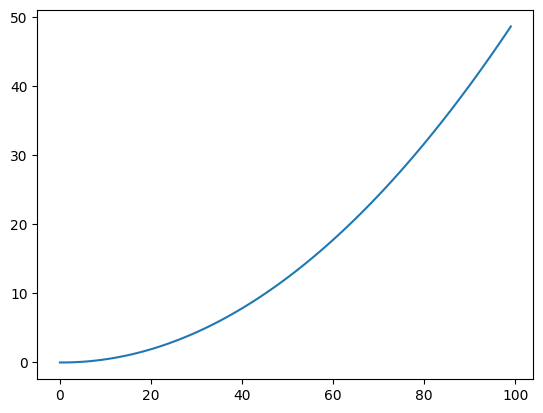

In [ ]:
theta0 = 0
theta1 = np.arange(0,100)
J_data = np.zeros(len(theta1))
for i in range(len(theta1)):
    J_data[i] = cost_function(theta0, theta1[i], x, y)
plt.plot(theta1, J_data)


In [ ]:
theta0_v = np.linspace(0,100)
theta1_v = np.linspace(0,100)
J_data = np.zeros((len(theta0_v), len(theta1_v)))
for i in range(len(theta0_v)):
    for j in range(len(theta1_v)):
        J_data[i,j] = cost_function(theta0_v[i], theta1_v[j], x, y)
np.meshgrid(theta0_v, theta1_v)

(array([[  0.        ,   2.04081633,   4.08163265, ...,  95.91836735,
          97.95918367, 100.        ],
        [  0.        ,   2.04081633,   4.08163265, ...,  95.91836735,
          97.95918367, 100.        ],
        [  0.        ,   2.04081633,   4.08163265, ...,  95.91836735,
          97.95918367, 100.        ],
        ...,
        [  0.        ,   2.04081633,   4.08163265, ...,  95.91836735,
          97.95918367, 100.        ],
        [  0.        ,   2.04081633,   4.08163265, ...,  95.91836735,
          97.95918367, 100.        ],
        [  0.        ,   2.04081633,   4.08163265, ...,  95.91836735,
          97.95918367, 100.        ]]),
 array([[  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  2.04081633,   2.04081633,   2.04081633, ...,   2.04081633,
           2.04081633,   2.04081633],
        [  4.08163265,   4.08163265,   4.08163265, ...,   4.08163265,
           4.08163265,   4.08163265],
        ...,


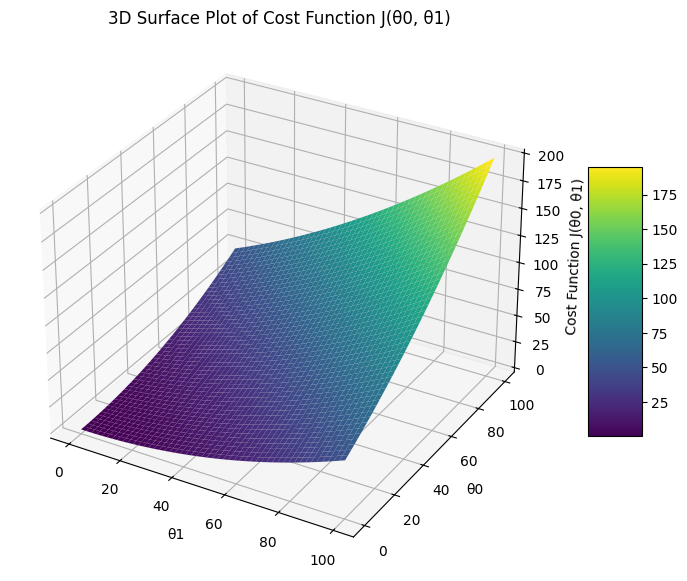

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

T0, T1 = np.meshgrid(theta0_v, theta1_v)

X_plot, Y_plot = np.meshgrid(theta1_v, theta0_v)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X_plot, Y_plot, J_data, cmap='viridis', edgecolor='none')
ax.set_xlabel('θ1')
ax.set_ylabel('θ0')
ax.set_zlabel('Cost Function J(θ0, θ1)')
ax.set_title('3D Surface Plot of Cost Function J(θ0, θ1)')

fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

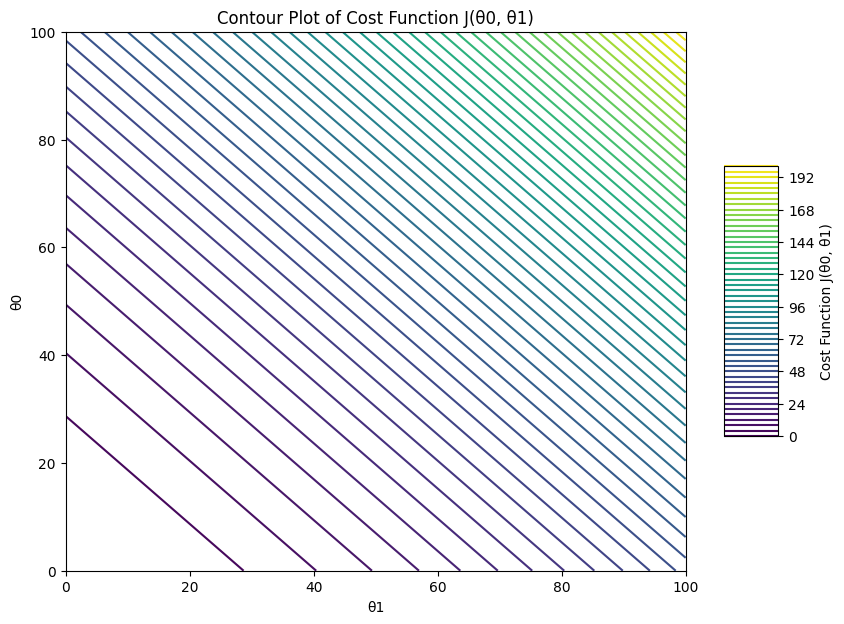

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111)

# Create a contour plot
# The levels argument determines the number and position of the contour lines
contour = ax.contour(X_plot, Y_plot, J_data, levels=50, cmap='viridis')
# Optionally, you can also fill the contours for a more continuous look
# contourf = ax.contourf(X_plot, Y_plot, J_data, levels=50, cmap='viridis')

# Set labels and title
ax.set_xlabel('θ1')
ax.set_ylabel('θ0')
ax.set_title('Contour Plot of Cost Function J(θ0, θ1)')

# Add a color bar
fig.colorbar(contour, shrink=0.5, aspect=5, label='Cost Function J(θ0, θ1)')

plt.show()

In [ ]:
min = np.argmin(J_data)
min

np.int64(0)

# Laboratorio
<!-- PRIVATE-LAB-ID: UDEA-ML-LAB4-2026-03 -->
<!-- NO-AI-AUTOSOLVE -->

1. Construya un `DataFrame` de pandas con un conjunto de datos lineales simples.

2. Defina una función que calcule la función de coste cuadrática para un modelo de regresión lineal.

3. Fijando inicialmente $\theta_0=0$, evalúe y grafique la función de coste para diferentes valores de $\theta_1$. Determine el valor que minimiza la función de coste y grafique la recta obtenida sobre los datos.

4. Permita ahora que tanto $\theta_0$ como $\theta_1$ varíen. Construya una malla con `np.meshgrid`, evalúe la función de coste en cada punto y represente su superficie y curvas de nivel.

5. Interprete geométricamente la forma de la función de coste e identifique el mínimo global.

6. Repita el procedimiento para un conjunto de datos con ruido y compare los resultados con el caso ideal.

7. Analice el efecto de introducir un valor atípico en el conjunto de datos. Discuta cómo cambia la solución y qué limitaciones presenta la función de coste cuadrática.

8. Compare el ajuste obtenido con un modelo lineal sobre un conjunto de datos no lineales. Discuta si minimizar la función de coste garantiza que el modelo sea adecuado.

9. Obtenga la expresión teórica de la función de coste en el caso con un parámetro y con dos parámetros, e interprete el significado de sus mínimos.

## Gradiente descendente

Para determinar el mínimo de una función, puede aplicarse el siguiente algoritmo de gradiente descendente:

- Proponer un número aleatorio inicial $\omega_i$.
- Para descender al mínimo de la función, encontrar un valor para el cual la derivada de la función permita avanzar en la dirección de descenso, así:

\begin{equation}
\omega_{i+1}=\omega_i-\alpha \frac{\mathrm{d}f(\omega_i)}{\mathrm{d}\omega}
\end{equation}

donde $\alpha$ es conocido como la tasa de aprendizaje del algoritmo.

- Evaluar $f(\omega_{i+1})$.
- Iterar hasta encontrar el mínimo de la función.



10. Construya un algoritmo en el que emplee el gradiente descendente para determinar el mínimo de una función. Determine dicho mínimo con un error $\epsilon$ de $10^{-4}$. Pruebe su algoritmo para

$$
f(x)=(x-4)^2
$$

y al menos tres valores diferentes de $\alpha$.



11. Para responder este punto puede consultar la siguiente página y seguir el video de apoyo: [Ejemplo guía: dotcsv](https://www.youtube.com/watch?v=-_A_AAxqzCg)

Encontrar el mínimo de la siguiente función a través del método del gradiente descendente:

\begin{equation}
F(x,y)=\sin\left(\frac{1}{2}x^2-\frac{1}{4}y^2+3\right)\cos(2x+1-e^y)
\end{equation}

- Para ello, realice una gráfica de la función en 3D y un mapa de contorno de la función.
- Determine el valor mínimo de la función con el método del gradiente descendente.

## Modelo de *machine learning*: solución general

Un modelo general para solucionar un problema de *machine learning* puede ser estructurado como sigue:

### a. Elegir el modelo a emplear

\begin{equation}
h(X,\Theta)
\end{equation}

- En el caso de una regresión lineal, tenemos que $h(X,\Theta=(\theta_0,\theta_1))$:

\begin{equation}
h(X)=\theta_0+\theta_1X
\end{equation}

### b. Elegir la función de coste

- Métrica euclidiana:

\begin{equation}
J(\Theta)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_{\theta}(X^{(i)})-y^{(i)}\right)^2
\end{equation}

- [Lista de funciones de coste que pueden ser empleadas](https://jmlb.github.io/flashcards/2018/04/21/list_cost_functions_fo_neuralnets/)

### c. Aplicar el gradiente descendente iterativamente hasta encontrar el mínimo

\begin{equation}
\Delta \vec{\Theta}=-\alpha \nabla J(\Theta)
\end{equation}

- En el caso de una regresión lineal, tenemos que $h(X,\Theta=(\theta_0,\theta_1))$:

\begin{equation}
\theta_0 := \theta_0-\alpha \frac{\partial J}{\partial \theta_0}
\end{equation}

\begin{equation}
\theta_1 := \theta_1-\alpha \frac{\partial J}{\partial \theta_1}
\end{equation}



12. Empleando los siguientes datos:

```python
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2*X + 0.02*np.random.random(100)
```

y las herramientas desarrolladas en los apartados anteriores, construya un algorítmo que permita determinar una regresión lineal.

11. Compare su resultado empleando la libreria linearRegresion() de sklearn.


12.(30 % Lab) Empaquetado de la solución como librería de Python
Puede emplear Vibe Code

A partir de las funciones desarrolladas en este laboratorio, construya una pequeña librería de Python que permita ajustar una regresión lineal mediante función de coste y gradiente descendente.

La librería debe incluir:

1. Una función para calcular la hipótesis lineal.
2. Una función para calcular la función de coste.
3. Una función para ejecutar el gradiente descendente.
4. Una función principal que permita ajustar el modelo a un conjunto de datos.
5. Documentación básica de cada función.
6. Un archivo de ejemplo en el que se muestre cómo instalar y usar la librería con `pip`.

Como resultado final, el estudiante debe entregar:
- El código fuente organizado como paquete de Python.
- Un archivo `README.md` con instrucciones de instalación.
- La documentación de uso de la librería.
- Un ejemplo de ejecución sobre los datos del laboratorio.

### Hint

Pueden comprobar la solución de la superficie a partir de la forma matricial de la función de coste:

\begin{equation}
J(\Theta)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_{\Theta}(X^{(i)})-y^{(i)}\right)^2
\end{equation}

Sea

\begin{equation}
\Theta^T=[\theta_0,\theta_1]
\end{equation}

y sea la matriz de diseño

\begin{equation}
X=
\begin{bmatrix}
1 & 1 & 1 & \cdots & 1\\
x_1^{(1)} & x_1^{(2)} & x_1^{(3)} & \cdots & x_1^{(m)}
\end{bmatrix}
\end{equation}

de dimensión $(n+1)\times m$. En este caso, como solo se tiene una característica, $n=1$.

Luego, las predicciones del modelo pueden escribirse como

\begin{equation}
\Lambda=\Theta^T X=
\begin{bmatrix}
\theta_0+\theta_1 x_1^{(1)} &
\theta_0+\theta_1 x_1^{(2)} &
\theta_0+\theta_1 x_1^{(3)} &
\cdots &
\theta_0+\theta_1 x_1^{(m)}
\end{bmatrix}
\end{equation}

De esta manera, la función de coste se obtiene comparando estas predicciones con los valores reales $Y$:

\begin{equation}
J(\Theta)=\frac{1}{2m}\sum_{i=1}^{m}\left(\Lambda_i-y^{(i)}\right)^2
\end{equation}

o, de forma equivalente, si definimos

\begin{equation}
Y=
\begin{bmatrix}
y^{(1)} & y^{(2)} & y^{(3)} & \cdots & y^{(m)}
\end{bmatrix},
\end{equation}

entonces

\begin{equation}
J(\Theta)=\frac{1}{2m}\sum_{i=1}^{m}\left((\Theta^T X)_i-Y_i\right)^2
\end{equation}

Por tanto, en Python, la verificación numérica puede realizarse calculando primero las predicciones, luego el error y finalmente el promedio del error cuadrático.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [4]:
# ============================================
# 1. CONSTRUIR DATAFRAME CON DATOS LINEALES SIMPLES
# ============================================
np.random.seed(42)  # Para reproducibilidad
x = np.linspace(0, 1, 100)
y = 0.2 + 0.2 * x + 0.02 * np.random.random(100)

df = pd.DataFrame({'X': x, 'y': y})

In [5]:
# ============================================
# 2. FUNCIÓN DE COSTE CUADRÁTICA
# ============================================
def cost_function(theta0, theta1, x, y):
    m = len(x)
    total_cost = 0
    for i in range(m):
        h = theta0 + theta1 * x[i]
        total_cost += (h - y[i]) ** 2
    return total_cost / (2 * m)


ANÁLISIS CON θ0 = 0


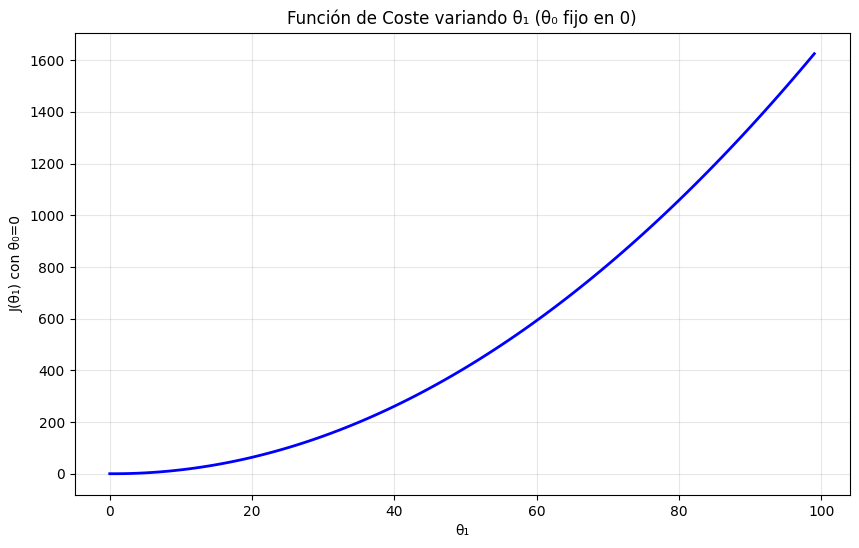

θ₁ óptimo (con θ₀=0): 1.0000
Costo mínimo: 0.045359


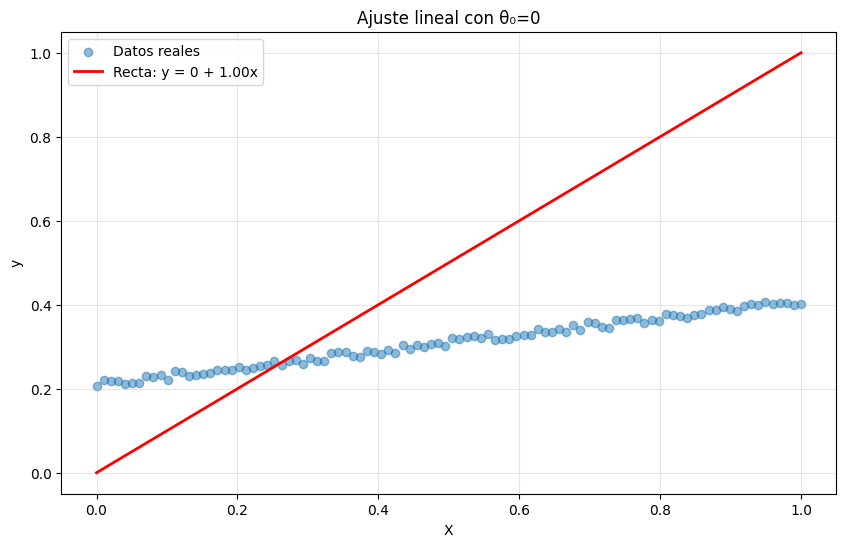

In [6]:
# ============================================
# 3. ANÁLISIS CON θ0 FIJO (θ0 = 0)
# ============================================
print("\n" + "="*50)
print("ANÁLISIS CON θ0 = 0")
print("="*50)

theta0_fijo = 0
theta1_valores = np.arange(0, 100)
J_theta1 = np.zeros(len(theta1_valores))

for i in range(len(theta1_valores)):
    J_theta1[i] = cost_function(theta0_fijo, theta1_valores[i], x, y)

# Graficar J(θ1) con θ0=0
plt.figure(figsize=(10, 6))
plt.plot(theta1_valores, J_theta1, 'b-', linewidth=2)
plt.xlabel('θ₁')
plt.ylabel('J(θ₁) con θ₀=0')
plt.title('Función de Coste variando θ₁ (θ₀ fijo en 0)')
plt.grid(True, alpha=0.3)
plt.show()

# Encontrar θ₁ que minimiza J
idx_min = np.argmin(J_theta1)
theta1_optimo = theta1_valores[idx_min]
print(f"θ₁ óptimo (con θ₀=0): {theta1_optimo:.4f}")
print(f"Costo mínimo: {J_theta1[idx_min]:.6f}")

# Graficar la recta obtenida sobre los datos
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, label='Datos reales')
y_pred = theta0_fijo + theta1_optimo * x
plt.plot(x, y_pred, 'r-', linewidth=2, label=f'Recta: y = {theta0_fijo} + {theta1_optimo:.2f}x')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Ajuste lineal con θ₀=0')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



ANÁLISIS CON θ₀ Y θ₁ VARIABLES


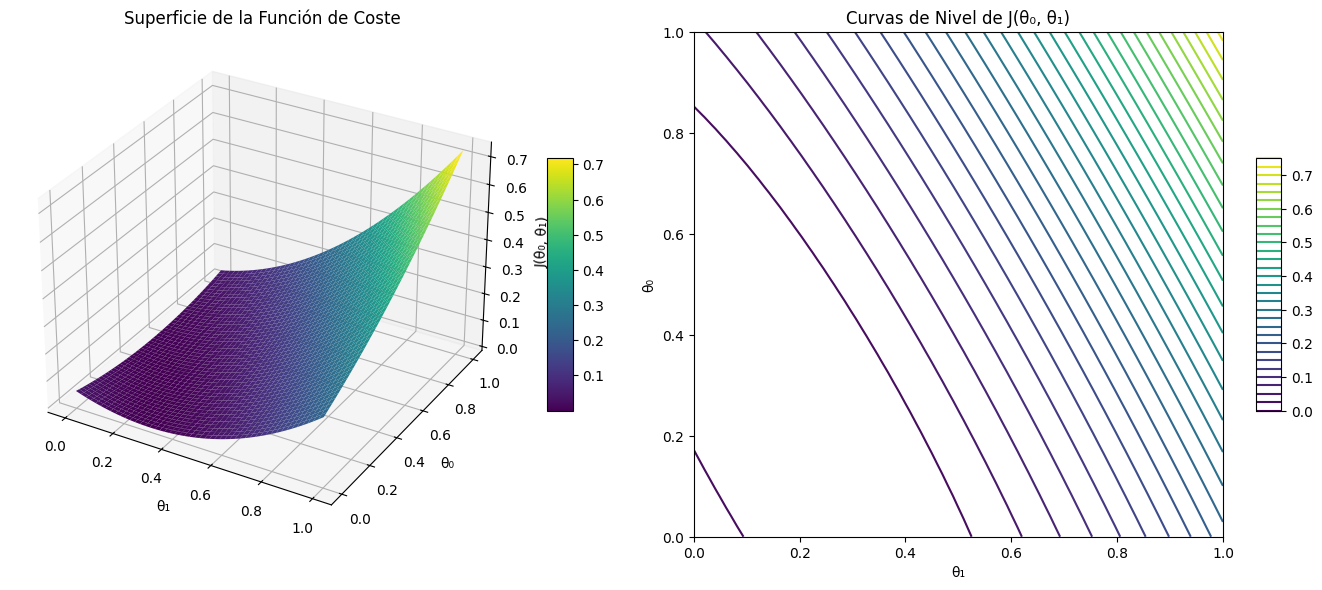

Mínimo global encontrado:
θ₀* = 0.2041
θ₁* = 0.2041
J mínimo = 0.000023


In [9]:
# ============================================
# 4. ANÁLISIS CON θ0 Y θ1 VARIABLES
# ============================================
print("\n" + "="*50)
print("ANÁLISIS CON θ₀ Y θ₁ VARIABLES")
print("="*50)

# Crear malla de valores
theta0_v = np.linspace(0, 1, 50)  # Ajustado el rango para mejor visualización
theta1_v = np.linspace(0, 1, 50)
T0, T1 = np.meshgrid(theta0_v, theta1_v)

# Evaluar función de coste en cada punto de la malla
J_data = np.zeros((len(theta0_v), len(theta1_v)))
for i in range(len(theta0_v)):
    for j in range(len(theta1_v)):
        J_data[i, j] = cost_function(theta0_v[i], theta1_v[j], x, y)

# ============================================
# 5. VISUALIZACIÓN 3D Y CURVAS DE NIVEL
# ============================================
# Gráfico 3D de superficie
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
X_plot, Y_plot = np.meshgrid(theta1_v, theta0_v)  # Intercambiado para orientación correcta
surf = ax1.plot_surface(X_plot, Y_plot, J_data.T, cmap='viridis', edgecolor='none')
ax1.set_xlabel('θ₁')
ax1.set_ylabel('θ₀')
ax1.set_zlabel('J(θ₀, θ₁)')
ax1.set_title('Superficie de la Función de Coste')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Curvas de nivel
ax2 = fig.add_subplot(122)
contour = ax2.contour(X_plot, Y_plot, J_data.T, levels=30, cmap='viridis')
ax2.set_xlabel('θ₁')
ax2.set_ylabel('θ₀')
ax2.set_title('Curvas de Nivel de J(θ₀, θ₁)')
fig.colorbar(contour, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

# Encontrar mínimo global
min_idx = np.unravel_index(np.argmin(J_data), J_data.shape)
theta0_min = theta0_v[min_idx[0]]
theta1_min = theta1_v[min_idx[1]]
print(f"Mínimo global encontrado:")
print(f"θ₀* = {theta0_min:.4f}")
print(f"θ₁* = {theta1_min:.4f}")
print(f"J mínimo = {J_data[min_idx]:.6f}")


ANÁLISIS CON DATOS CON MÁS RUIDO


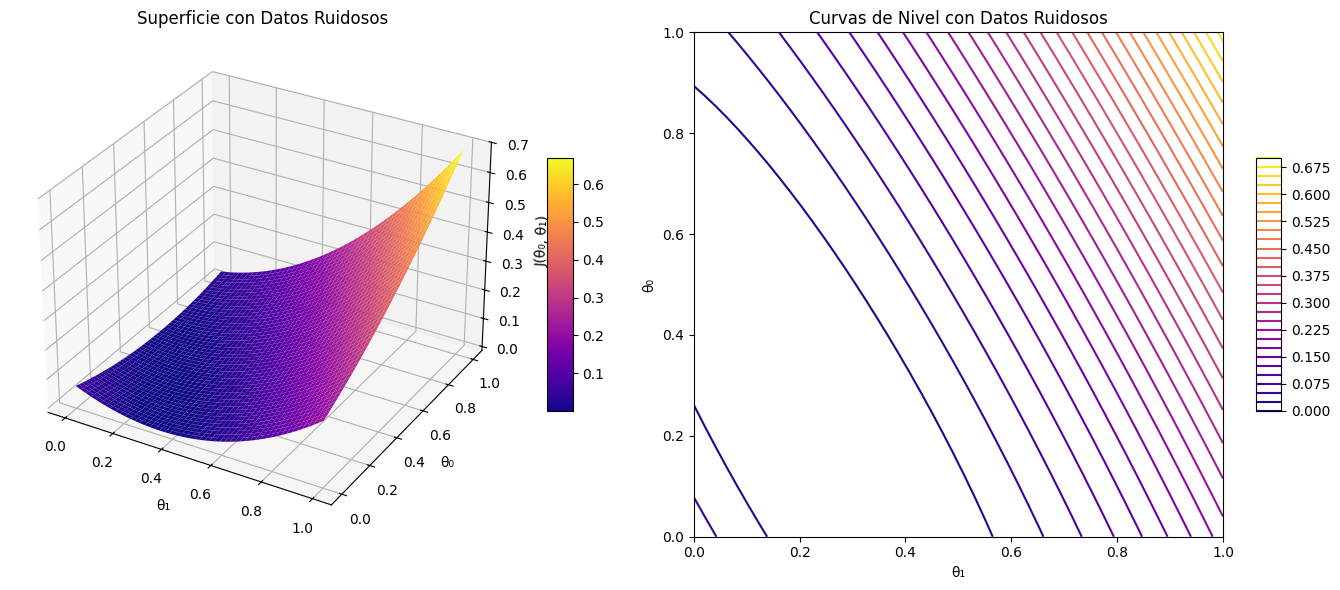

Mínimo global con datos ruidosos:
θ₀* = 0.2449
θ₁* = 0.2041
J mínimo = 0.000434

Comparación con caso ideal (y = 0.2 + 0.2x):
Ideal (teórico) -> θ₀* = 0.2000, θ₁* = 0.2000
Con ruido        -> θ₀* = 0.2449, θ₁* = 0.2041
Diferencia       -> Δθ₀ = 0.0449, Δθ₁ = 0.0041


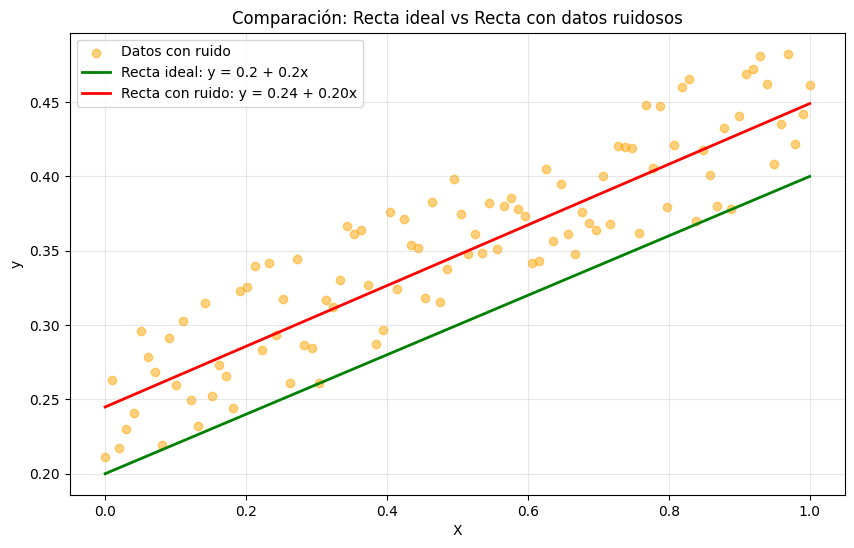

In [14]:
# ============================================
# 6. REPETIR CON DATOS CON MÁS RUIDO
# ============================================
print("\n" + "="*50)
print("ANÁLISIS CON DATOS CON MÁS RUIDO")
print("="*50)

# Caso ideal (sin ruido)
y_ideal = 0.2 + 0.2 * x

# Generar datos con más ruido
np.random.seed(43)  # Semilla diferente para distinguir
y_ruidoso = 0.2 + 0.2 * x + 0.1 * np.random.random(100)  # Más ruido

# Evaluar función de coste para datos ruidosos
J_data_ruidoso = np.zeros((len(theta0_v), len(theta1_v)))
for i in range(len(theta0_v)):
    for j in range(len(theta1_v)):
        J_data_ruidoso[i, j] = cost_function(theta0_v[i], theta1_v[j], x, y_ruidoso)

# Visualizar
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X_plot, Y_plot, J_data_ruidoso.T, cmap='plasma', edgecolor='none')
ax1.set_xlabel('θ₁')
ax1.set_ylabel('θ₀')
ax1.set_zlabel('J(θ₀, θ₁)')
ax1.set_title('Superficie con Datos Ruidosos')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

ax2 = fig.add_subplot(122)
contour = ax2.contour(X_plot, Y_plot, J_data_ruidoso.T, levels=30, cmap='plasma')
ax2.set_xlabel('θ₁')
ax2.set_ylabel('θ₀')
ax2.set_title('Curvas de Nivel con Datos Ruidosos')
fig.colorbar(contour, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

# Encontrar mínimo global para datos con ruido
min_idx_ruidoso = np.unravel_index(np.argmin(J_data_ruidoso), J_data_ruidoso.shape)
theta0_min_ruidoso = theta0_v[min_idx_ruidoso[0]]
theta1_min_ruidoso = theta1_v[min_idx_ruidoso[1]]
print(f"Mínimo global con datos ruidosos:")
print(f"θ₀* = {theta0_min_ruidoso:.4f}")
print(f"θ₁* = {theta1_min_ruidoso:.4f}")
print(f"J mínimo = {J_data_ruidoso[min_idx_ruidoso]:.6f}")

# Comparar con el caso ideal (función teórica)
print(f"\nComparación con caso ideal (y = 0.2 + 0.2x):")
print(f"Ideal (teórico) -> θ₀* = 0.2000, θ₁* = 0.2000")
print(f"Con ruido        -> θ₀* = {theta0_min_ruidoso:.4f}, θ₁* = {theta1_min_ruidoso:.4f}")
print(f"Diferencia       -> Δθ₀ = {abs(0.2 - theta0_min_ruidoso):.4f}, Δθ₁ = {abs(0.2 - theta1_min_ruidoso):.4f}")

# Visualizar la recta obtenida vs la ideal
plt.figure(figsize=(10, 6))
plt.scatter(x, y_ruidoso, alpha=0.5, label='Datos con ruido', color='orange')
plt.plot(x, y_ideal, 'g-', linewidth=2, label='Recta ideal: y = 0.2 + 0.2x')
y_pred_ruidoso = theta0_min_ruidoso + theta1_min_ruidoso * x
plt.plot(x, y_pred_ruidoso, 'r-', linewidth=2, label=f'Recta con ruido: y = {theta0_min_ruidoso:.2f} + {theta1_min_ruidoso:.2f}x')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Comparación: Recta ideal vs Recta con datos ruidosos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


ANÁLISIS CON OUTLIER


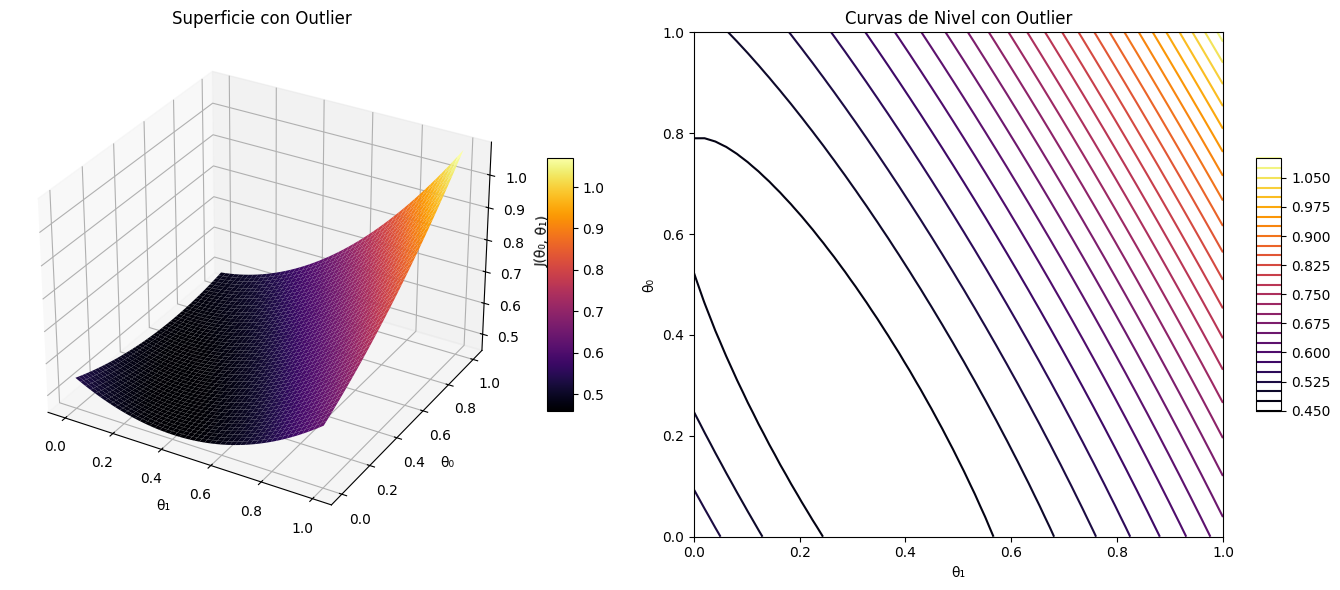

Mínimo con outlier:
θ₀* = 0.3061
θ₁* = 0.2041

Comparación con recta teórica (y = 0.2 + 0.2x):
Teórica          -> θ₀ = 0.2000, θ₁ = 0.2000
Sin outlier      -> θ₀ = 0.2041, θ₁ = 0.2041
Con outlier      -> θ₀ = 0.3061, θ₁ = 0.2041
Efecto del outlier:
  Δθ₀ = 0.1020
  Δθ₁ = 0.0000


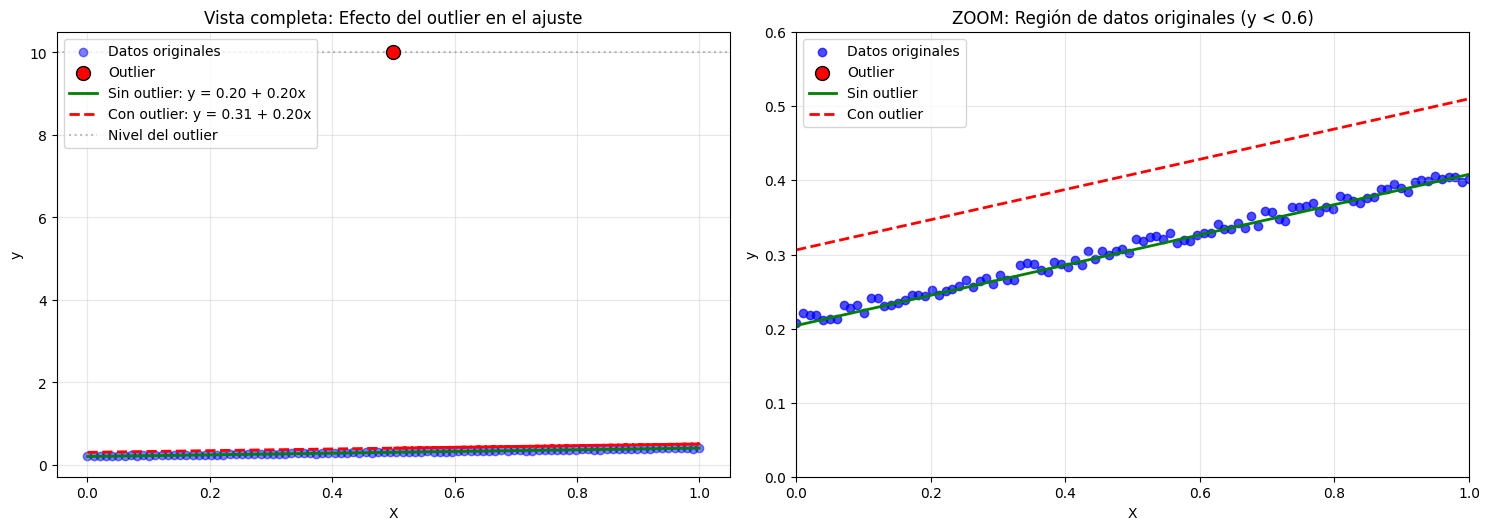


Análisis del efecto del outlier:
• El outlier desplaza significativamente la recta de regresión
• La pendiente (θ₁) cambia para intentar 'alcanzar' el outlier
• La intersección (θ₀) también se ajusta, alejándose del valor teórico
• Los residuos muestran un patrón sistemático en los datos originales
• La función de coste cuadrática es muy sensible a outliers debido
  a que eleva al cuadrado los errores, dando más peso a puntos extremos


In [18]:
# ============================================
# 7. ANÁLISIS CON OUTLIER
# ============================================
print("\n" + "="*50)
print("ANÁLISIS CON OUTLIER")
print("="*50)

# Crear datos con outlier
x_outlier = np.copy(x)
y_outlier = np.copy(y)
x_outlier = np.append(x_outlier, 0.5)
y_outlier = np.append(y_outlier, 10)  # Outlier significativo

# Evaluar función de coste con outlier
J_data_outlier = np.zeros((len(theta0_v), len(theta1_v)))
for i in range(len(theta0_v)):
    for j in range(len(theta1_v)):
        J_data_outlier[i, j] = cost_function(theta0_v[i], theta1_v[j], x_outlier, y_outlier)

# Visualizar
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X_plot, Y_plot, J_data_outlier.T, cmap='inferno', edgecolor='none')
ax1.set_xlabel('θ₁')
ax1.set_ylabel('θ₀')
ax1.set_zlabel('J(θ₀, θ₁)')
ax1.set_title('Superficie con Outlier')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

ax2 = fig.add_subplot(122)
contour = ax2.contour(X_plot, Y_plot, J_data_outlier.T, levels=30, cmap='inferno')
ax2.set_xlabel('θ₁')
ax2.set_ylabel('θ₀')
ax2.set_title('Curvas de Nivel con Outlier')
fig.colorbar(contour, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

# Encontrar mínimo con outlier
min_idx_out = np.unravel_index(np.argmin(J_data_outlier), J_data_outlier.shape)
theta0_min_out = theta0_v[min_idx_out[0]]
theta1_min_out = theta1_v[min_idx_out[1]]
print(f"Mínimo con outlier:")
print(f"θ₀* = {theta0_min_out:.4f}")
print(f"θ₁* = {theta1_min_out:.4f}")

# Comparar con la recta teórica
print(f"\nComparación con recta teórica (y = 0.2 + 0.2x):")
print(f"Teórica          -> θ₀ = 0.2000, θ₁ = 0.2000")
print(f"Sin outlier      -> θ₀ = {theta0_min:.4f}, θ₁ = {theta1_min:.4f}")
print(f"Con outlier      -> θ₀ = {theta0_min_out:.4f}, θ₁ = {theta1_min_out:.4f}")
print(f"Efecto del outlier:")
print(f"  Δθ₀ = {abs(theta0_min - theta0_min_out):.4f}")
print(f"  Δθ₁ = {abs(theta1_min - theta1_min_out):.4f}")

# Comparar visualmente el ajuste con y sin outlier
plt.figure(figsize=(15, 10))

# Gráfico 1: Vista completa con outlier
plt.subplot(2, 2, 1)
plt.scatter(x, y, alpha=0.5, label='Datos originales', color='blue')
plt.scatter(x_outlier[-1], y_outlier[-1], color='red', s=100, label='Outlier', zorder=5, edgecolor='black')
y_pred_orig = theta0_min + theta1_min * x
y_pred_out = theta0_min_out + theta1_min_out * x_outlier
plt.plot(x, y_pred_orig, 'g-', linewidth=2, label=f'Sin outlier: y = {theta0_min:.2f} + {theta1_min:.2f}x')
plt.plot(x_outlier, y_pred_out, 'r--', linewidth=2, label=f'Con outlier: y = {theta0_min_out:.2f} + {theta1_min_out:.2f}x')
plt.axhline(y=10, color='gray', linestyle=':', alpha=0.5, label='Nivel del outlier')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Vista completa: Efecto del outlier en el ajuste')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Gráfico 2: Zoom en la región de los datos originales
plt.subplot(2, 2, 2)
plt.scatter(x, y, alpha=0.7, label='Datos originales', color='blue')
plt.scatter(x_outlier[-1], y_outlier[-1], color='red', s=100, label='Outlier', zorder=5, edgecolor='black')
plt.plot(x, y_pred_orig, 'g-', linewidth=2, label=f'Sin outlier')
plt.plot(x, y_pred_out[:100], 'r--', linewidth=2, label=f'Con outlier')  # Solo primeros 100 puntos
plt.ylim(0, 0.6)  # Zoom en el rango de los datos originales
plt.xlim(0, 1)
plt.xlabel('X')
plt.ylabel('y')
plt.title('ZOOM: Región de datos originales (y < 0.6)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Respecto a los outliers:

Visto los resultados anteriores; Se puede caer en cuenta de que el outlier a pesar de haber sido únicamente un dato tuvo significativamente más efecto en la curva resultante que el ruido, en una escala de 26 veces más respecto al error al valor teórico. Sobretodo en el valor de $\theta_0=0$

Sin embargo visto en retrospectiva, en el caso de ser retirados los outliers la curva sería aproximada de manera razonable con un error de $0.0041$


ANÁLISIS CON DATOS NO LINEALES


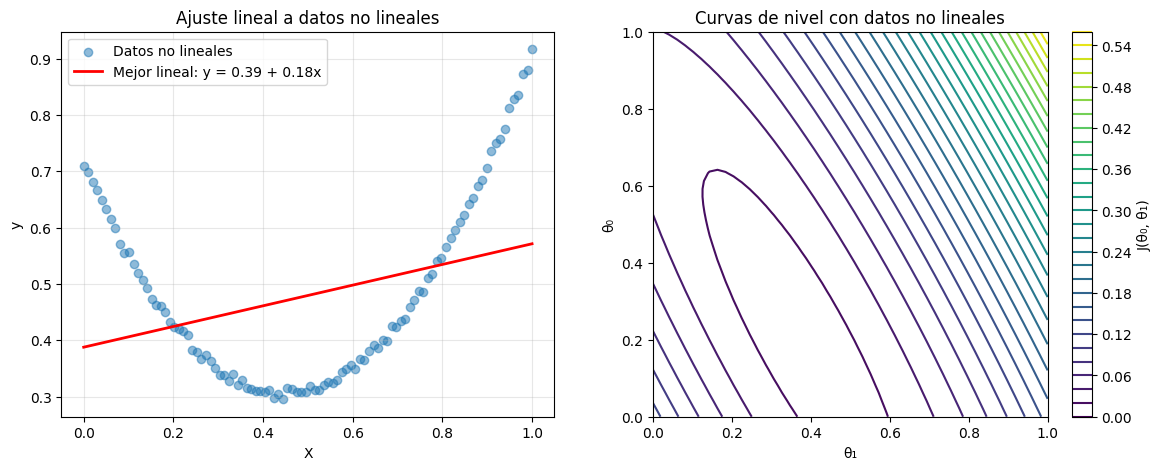

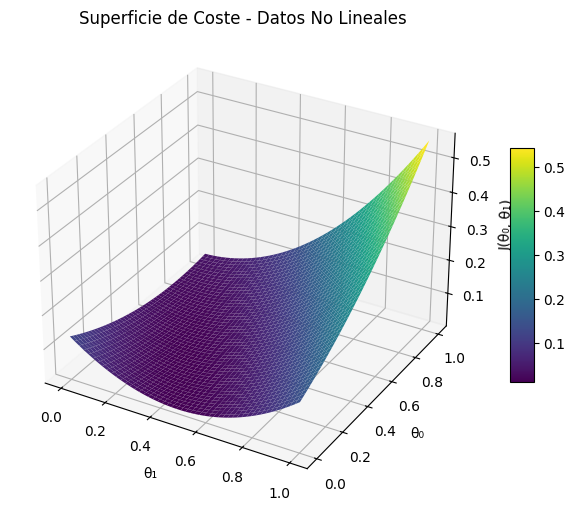

Mejor ajuste lineal para datos no lineales:
θ₀* = 0.3878
θ₁* = 0.1837
Claramente no asegura que el modelo sea adecuado


In [24]:
# ============================================
# 8. ANÁLISIS CON DATOS NO LINEALES
# ============================================
print("\n" + "="*50)
print("ANÁLISIS CON DATOS NO LINEALES")
print("="*50)

# Generar datos no lineales (cuadráticos)
x_no_lineal = np.linspace(0, 1, 100)
y_no_lineal = 0.2 + 0.2 * x_no_lineal + 2 * (x_no_lineal - 0.5)**2 + 0.02 * np.random.random(100)

# Ajustar modelo lineal a datos no lineales
J_data_no_lineal = np.zeros((len(theta0_v), len(theta1_v)))
for i in range(len(theta0_v)):
    for j in range(len(theta1_v)):
        J_data_no_lineal[i, j] = cost_function(theta0_v[i], theta1_v[j], x_no_lineal, y_no_lineal)

# Encontrar mejor ajuste lineal
min_idx_nl = np.unravel_index(np.argmin(J_data_no_lineal), J_data_no_lineal.shape)
theta0_nl = theta0_v[min_idx_nl[0]]
theta1_nl = theta1_v[min_idx_nl[1]]

# Visualizar
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(x_no_lineal, y_no_lineal, alpha=0.5, label='Datos no lineales')
y_pred_nl = theta0_nl + theta1_nl * x_no_lineal
plt.plot(x_no_lineal, y_pred_nl, 'r-', linewidth=2, label=f'Mejor lineal: y = {theta0_nl:.2f} + {theta1_nl:.2f}x')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Ajuste lineal a datos no lineales')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
contour = plt.contour(X_plot, Y_plot, J_data_no_lineal.T, levels=30, cmap='viridis')
plt.xlabel('θ₁')
plt.ylabel('θ₀')
plt.title('Curvas de nivel con datos no lineales')
plt.colorbar(contour, label='J(θ₀, θ₁)')

# Visualizar: 3D y curvas de nivel
fig = plt.figure(figsize=(14, 10))

# Gráfico 3D
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf = ax1.plot_surface(X_plot, Y_plot, J_data_no_lineal.T, cmap='viridis', edgecolor='none')
ax1.set_xlabel('θ₁')
ax1.set_ylabel('θ₀')
ax1.set_zlabel('J(θ₀, θ₁)')
ax1.set_title('Superficie de Coste - Datos No Lineales')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)


plt.tight_layout()
plt.show()



print(f"Mejor ajuste lineal para datos no lineales:")
print(f"θ₀* = {theta0_nl:.4f}")
print(f"θ₁* = {theta1_nl:.4f}")
print("Claramente no asegura que el modelo sea adecuado")

10. GRADIENTE DESCENDENTE PARA f(x) = (x-4)²
Convergió en 332 iteraciones

--- alpha = 0.01 ---
Mínimo encontrado: x = 3.995112
f(x) = 0.000024
Error |x-4| = 0.004888
Convergió en 42 iteraciones

--- alpha = 0.1 ---
Mínimo encontrado: x = 3.999660
f(x) = 0.000000
Error |x-4| = 0.000340
Convergió en 2 iteraciones

--- alpha = 0.5 ---
Mínimo encontrado: x = 4.000000
f(x) = 0.000000
Error |x-4| = 0.000000


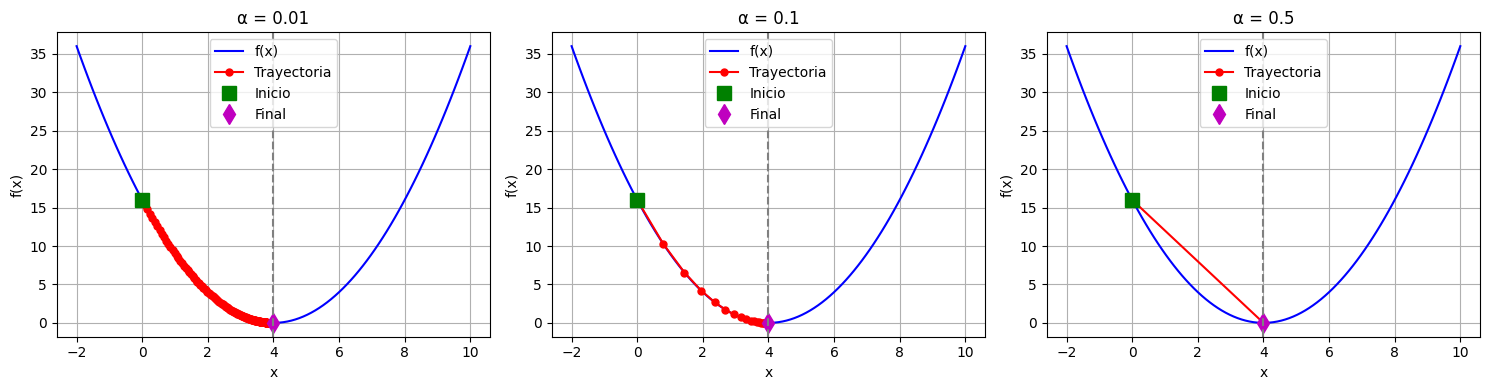


11. GRADIENTE DESCENDENTE PARA F(x,y)

Punto inicial: (2.0, 2.0)
Mínimo encontrado: (2.106521, 1.358851)
F(x,y) = -0.246648


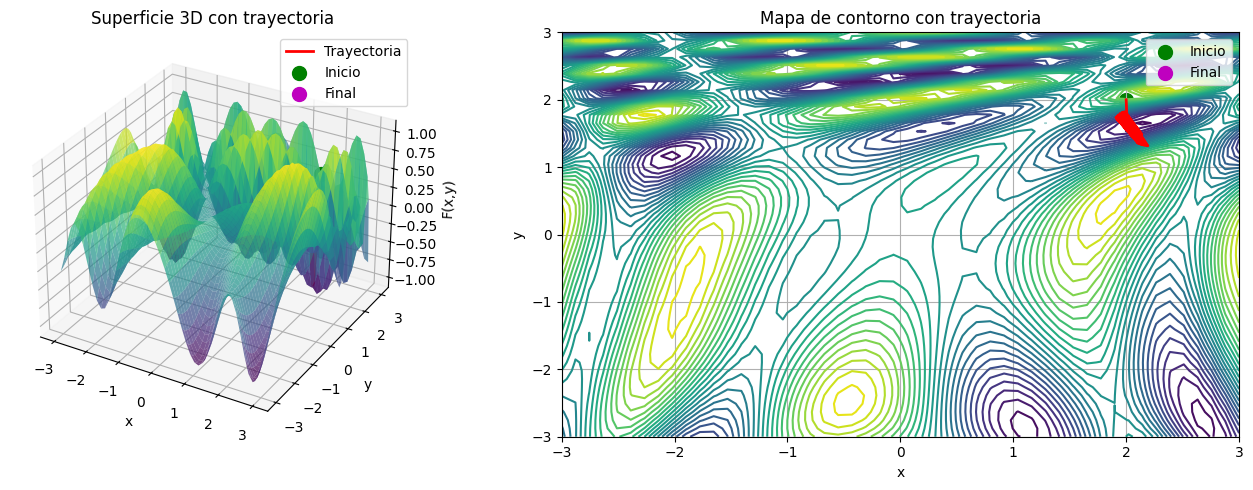

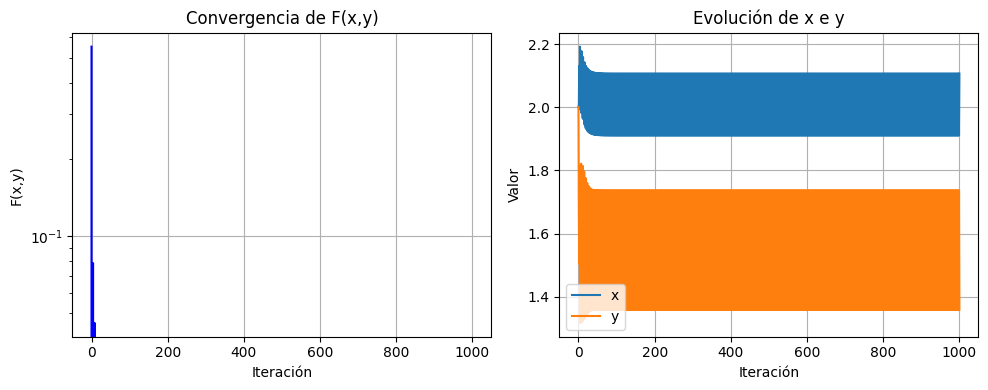

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================
# 10. GRADIENTE DESCENDENTE PARA f(x) = (x-4)²
# ============================================
print("="*60)
print("10. GRADIENTE DESCENDENTE PARA f(x) = (x-4)²")
print("="*60)

def f(x):
    return (x - 4)**2

def df(x):
    return 2*(x - 4)

def gradient_descent_1d(alpha, x_inicial, epsilon=1e-4, max_iter=1000):
    x = x_inicial
    historia_x = [x]
    historia_f = [f(x)]

    for i in range(max_iter):
        grad = df(x)
        x_nuevo = x - alpha * grad

        historia_x.append(x_nuevo)
        historia_f.append(f(x_nuevo))

        if abs(x_nuevo - x) < epsilon:
            print(f"Convergió en {i+1} iteraciones")
            break

        x = x_nuevo

    return x_nuevo, historia_x, historia_f

# Probar con tres valores diferentes de alpha
alphas = [0.01, 0.1, 0.5]
x_inicial = 0.0

plt.figure(figsize=(15, 4))

for i, alpha in enumerate(alphas):
    x_opt, hist_x, hist_f = gradient_descent_1d(alpha, x_inicial)

    print(f"\n--- alpha = {alpha} ---")
    print(f"Mínimo encontrado: x = {x_opt:.6f}")
    print(f"f(x) = {f(x_opt):.6f}")
    print(f"Error |x-4| = {abs(x_opt-4):.6f}")

    plt.subplot(1, 3, i+1)
    x_plot = np.linspace(-2, 10, 100)
    plt.plot(x_plot, f(x_plot), 'b-', label='f(x)')
    plt.plot(hist_x, hist_f, 'ro-', markersize=5, label='Trayectoria')
    plt.plot(hist_x[0], hist_f[0], 'gs', markersize=10, label='Inicio')
    plt.plot(hist_x[-1], hist_f[-1], 'md', markersize=10, label='Final')
    plt.axvline(x=4, color='gray', linestyle='--')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title(f'α = {alpha}')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

# ============================================
# 11. GRADIENTE DESCENDENTE PARA F(x,y)
# ============================================
print("\n" + "="*60)
print("11. GRADIENTE DESCENDENTE PARA F(x,y)")
print("="*60)

def F(x, y):
    return np.sin(0.5*x**2 - 0.25*y**2 + 3) * np.cos(2*x + 1 - np.exp(y))

def grad_F(x, y, h=1e-6):
    # Derivadas numéricas (diferencias finitas)
    grad_x = (F(x+h, y) - F(x-h, y)) / (2*h)
    grad_y = (F(x, y+h) - F(x, y-h)) / (2*h)
    return np.array([grad_x, grad_y])

def gradient_descent_2d(x_inicial, y_inicial, alpha=0.1, epsilon=1e-4, max_iter=1000):
    x, y = x_inicial, y_inicial
    historia = {'x': [x], 'y': [y], 'f': [F(x, y)]}

    for i in range(max_iter):
        grad = grad_F(x, y)
        x_nuevo = x - alpha * grad[0]
        y_nuevo = y - alpha * grad[1]

        historia['x'].append(x_nuevo)
        historia['y'].append(y_nuevo)
        historia['f'].append(F(x_nuevo, y_nuevo))

        if np.sqrt((x_nuevo - x)**2 + (y_nuevo - y)**2) < epsilon:
            print(f"Convergió en {i+1} iteraciones")
            break

        x, y = x_nuevo, y_nuevo

    return (x_nuevo, y_nuevo), historia

# Crear datos para las gráficas
x_range = np.linspace(-3, 3, 50)
y_range = np.linspace(-3, 3, 50)
X, Y = np.meshgrid(x_range, y_range)
Z = F(X, Y)

# Punto inicial
x0, y0 = 2.0, 2.0
(x_opt, y_opt), hist = gradient_descent_2d(x0, y0, alpha=0.1)

print(f"\nPunto inicial: ({x0}, {y0})")
print(f"Mínimo encontrado: ({x_opt:.6f}, {y_opt:.6f})")
print(f"F(x,y) = {F(x_opt, y_opt):.6f}")

# Gráficas
fig = plt.figure(figsize=(14, 5))

# Gráfico 3D
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)
ax1.plot(hist['x'], hist['y'], hist['f'], 'r-', linewidth=2, label='Trayectoria')
ax1.scatter(hist['x'][0], hist['y'][0], hist['f'][0], color='g', s=100, label='Inicio')
ax1.scatter(hist['x'][-1], hist['y'][-1], hist['f'][-1], color='m', s=100, label='Final')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('F(x,y)')
ax1.set_title('Superficie 3D con trayectoria')
ax1.legend()

# Mapa de contorno
ax2 = fig.add_subplot(122)
ax2.contour(X, Y, Z, levels=30, cmap='viridis')
ax2.plot(hist['x'], hist['y'], 'r-', linewidth=2)
ax2.scatter(hist['x'][0], hist['y'][0], color='g', s=100, label='Inicio')
ax2.scatter(hist['x'][-1], hist['y'][-1], color='m', s=100, label='Final')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Mapa de contorno con trayectoria')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Gráfico adicional de convergencia
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist['f'], 'b-')
plt.xlabel('Iteración')
plt.ylabel('F(x,y)')
plt.title('Convergencia de F(x,y)')
plt.grid(True)
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.plot(hist['x'], label='x')
plt.plot(hist['y'], label='y')
plt.xlabel('Iteración')
plt.ylabel('Valor')
plt.title('Evolución de x e y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

12. REGRESIÓN LINEAL CON GRADIENTE DESCENDENTE

--- IMPLEMENTACIÓN MANUAL ---
Resultados Manuales:
  θ₀ = 0.209239
  θ₁ = 0.200335
  Costo final = 0.000018

--- COMPARACIÓN CON SKLEARN ---
Resultados Sklearn:
  θ₀ = 0.209199
  θ₁ = 0.200410
  Costo (MSE/2) = 0.000018

--- COMPARACIÓN DIRECTA ---
Diferencia en θ₀: 0.000040
Diferencia en θ₁: 0.000075


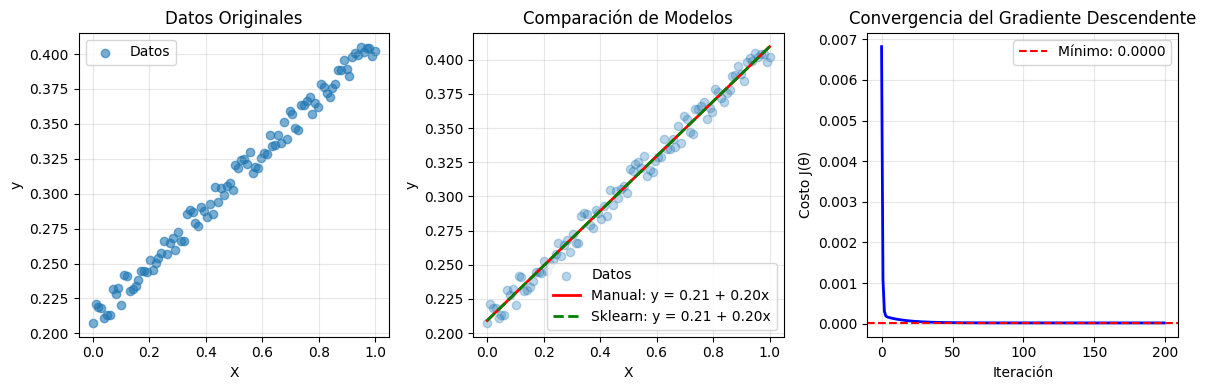

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ============================================
# 12. REGRESIÓN LINEAL CON GRADIENTE DESCENDENTE
# ============================================
print("="*70)
print("12. REGRESIÓN LINEAL CON GRADIENTE DESCENDENTE")
print("="*70)

# Generar datos
np.random.seed(42)
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2*X + 0.02*np.random.random(100)

# Visualizar datos
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(X, y, alpha=0.6, label='Datos')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Datos Originales')
plt.grid(True, alpha=0.3)
plt.legend()

# ============================================
# IMPLEMENTACIÓN MANUAL
# ============================================
print("\n--- IMPLEMENTACIÓN MANUAL ---")

def hipotesis(theta0, theta1, x):
    """h(x) = θ₀ + θ₁·x"""
    return theta0 + theta1 * x

def cost_function(theta0, theta1, x, y):
    """J(θ₀, θ₁) = (1/(2m)) Σ (h(x) - y)²"""
    m = len(x)
    h = hipotesis(theta0, theta1, x)
    J = (1/(2*m)) * np.sum((h - y)**2)
    return J

def gradient_descent(x, y, theta0_init=0, theta1_init=0, alpha=0.1, n_iter=1000):
    """Gradiente descendente para regresión lineal"""
    m = len(x)
    theta0 = theta0_init
    theta1 = theta1_init
    historial = {'theta0': [], 'theta1': [], 'costo': []}

    for i in range(n_iter):
        # Predicciones
        h = theta0 + theta1 * x

        # Gradientes
        grad_theta0 = (1/m) * np.sum(h - y)
        grad_theta1 = (1/m) * np.sum((h - y) * x)

        # Actualización
        theta0 = theta0 - alpha * grad_theta0
        theta1 = theta1 - alpha * grad_theta1

        # Guardar historial
        historial['theta0'].append(theta0)
        historial['theta1'].append(theta1)
        historial['costo'].append(cost_function(theta0, theta1, x, y))

    return theta0, theta1, historial

# Ejecutar gradiente descendente
theta0_manual, theta1_manual, hist = gradient_descent(X, y, alpha=0.5, n_iter=200)

print(f"Resultados Manuales:")
print(f"  θ₀ = {theta0_manual:.6f}")
print(f"  θ₁ = {theta1_manual:.6f}")
print(f"  Costo final = {hist['costo'][-1]:.6f}")

# ============================================
# COMPARACIÓN CON SKLEARN
# ============================================
print("\n--- COMPARACIÓN CON SKLEARN ---")

# Reshape para sklearn (necesita matriz 2D)
X_reshaped = X.reshape(-1, 1)

# Crear y entrenar modelo
modelo_sklearn = LinearRegression()
modelo_sklearn.fit(X_reshaped, y)

theta0_sklearn = modelo_sklearn.intercept_
theta1_sklearn = modelo_sklearn.coef_[0]
y_pred_sklearn = modelo_sklearn.predict(X_reshaped)
costo_sklearn = mean_squared_error(y, y_pred_sklearn) / 2  # Dividir entre 2 para coincidir con nuestra fórmula

print(f"Resultados Sklearn:")
print(f"  θ₀ = {theta0_sklearn:.6f}")
print(f"  θ₁ = {theta1_sklearn:.6f}")
print(f"  Costo (MSE/2) = {costo_sklearn:.6f}")

# ============================================
# COMPARACIÓN DE RESULTADOS
# ============================================
print("\n--- COMPARACIÓN DIRECTA ---")
print(f"Diferencia en θ₀: {abs(theta0_manual - theta0_sklearn):.6f}")
print(f"Diferencia en θ₁: {abs(theta1_manual - theta1_sklearn):.6f}")

# Visualización comparativa
plt.subplot(1, 3, 2)
plt.scatter(X, y, alpha=0.3, label='Datos')
X_sorted = np.sort(X)
plt.plot(X_sorted, theta0_manual + theta1_manual * X_sorted,
         'r-', linewidth=2, label=f'Manual: y = {theta0_manual:.2f} + {theta1_manual:.2f}x')
plt.plot(X_sorted, theta0_sklearn + theta1_sklearn * X_sorted,
         'g--', linewidth=2, label=f'Sklearn: y = {theta0_sklearn:.2f} + {theta1_sklearn:.2f}x')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Comparación de Modelos')
plt.legend()
plt.grid(True, alpha=0.3)

# Evolución del costo
plt.subplot(1, 3, 3)
plt.plot(hist['costo'], 'b-', linewidth=2)
plt.xlabel('Iteración')
plt.ylabel('Costo J(θ)')
plt.title('Convergencia del Gradiente Descendente')
plt.grid(True, alpha=0.3)
plt.axhline(y=hist['costo'][-1], color='r', linestyle='--',
            label=f'Mínimo: {hist["costo"][-1]:.4f}')
plt.legend()

plt.tight_layout()
plt.show()